# DE-COP en BookTection — black-box, gratis (Colab)

Implementación de **DE-COP** (Duarte et al., 2024) sobre el benchmark **BookTection**
para *membership inference* en LLMs, en modo **black-box** (solo necesita la respuesta del modelo).

**Idea:** se le da al modelo una multiple-choice con el pasaje original *verbatim* + 3 paráfrasis
y se le pregunta cuál es el original. Si lo identifica consistentemente → señal de que lo vio en
el entrenamiento. Se promedia sobre permutaciones de las opciones (debiasing de posición) y se
calcula el **AUC** entre books *member* (Label=1) y *non-member* (Label=0).

Dos backends (elegís en la celda de config):
- **`groq`** → API gratis, sin GPU, OpenAI-compatible. Modelos: Llama-3.x, Gemma-2, Qwen, Mixtral.
  Ideal para tener resultados YA. ⚠️ Estos modelos tienen cutoff 2023+, así que los non-members
  de BookTection (libros 2023) están parcialmente contaminados → el AUC es un piso, no un número limpio.
- **`hf`** → corre el modelo vos en GPU (Colab T4 con tus créditos). Sirve para **Llama-2-7B**,
  que es el único temporalmente limpio para BookTection (cutoff ~sept 2022 → los libros 2023 son
  non-members reales). Llama-2 es *gated*: necesitás token de HF + aceptar la licencia.


## 1. Instalación

In [61]:
!pip install -q datasets scikit-learn pandas tqdm groq transformers accelerate python-dotenv

In [62]:
from groq import Groq
import glob
import shutil
import json
import pandas as pd
from sklearn.metrics import roc_auc_score
from pathlib import Path
import os

BASE_DIR = Path("simmia_decop")

API_LOG_DIR = BASE_DIR / "api_logs"
RESULTS_DIR = BASE_DIR / "results"

API_LOG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Resultados:", RESULTS_DIR)
print("Logs:", API_LOG_DIR)

# =========================================================
# GROQ API KEYS
# =========================================================
from dotenv import load_dotenv
load_dotenv()

api_keys = []

for i in range(1, 12):
    name = "GROQ_API_KEY" if i == 1 else f"GROQ_API_KEY{i}"
    key = os.getenv(name)

    if key:
        api_keys.append(key)

if not api_keys:
    raise RuntimeError(
        "No se encontraron API keys de Groq en las variables de entorno."
    )

print(f"Se cargaron {len(api_keys)} API Keys")

current_key = 0
client = Groq(api_key=api_keys[current_key])

# =========================================================
# HUGGING FACE TOKEN
# =========================================================

HF_TOKEN = os.getenv("HGF")

if HF_TOKEN:
    print("HF token cargado")
else:
    print("No se encontró HF_TOKEN")

Resultados: simmia_decop/results
Logs: simmia_decop/api_logs
Se cargaron 11 API Keys
HF token cargado


## 2. Configuración


In [63]:
# ----------------- CONFIG -----------------

BACKEND = "groq"  # "groq" o "hf"

MODEL = "llama-3.3-70b-versatile"
# MODEL = "llama-3.1-8b-instant"

# WikiMIA
WIKIMIA_LENGTH = 128

# Con 3 opciones existen 3! = 6 permutaciones
N_PERMUTATIONS = 6

# Rate limiting
SLEEP_BETWEEN_CALLS = 2.1

SEED = 2319

# ------------------------------------------

import os
from groq import Groq
from dotenv import load_dotenv

load_dotenv()

api_keys = []

for i in range(1, 12):
    name = "GROQ_API_KEY" if i == 1 else f"GROQ_API_KEY{i}"
    key = os.getenv(name)

    if key:
        api_keys.append(key)

if not api_keys:
    raise RuntimeError(
        "No se encontraron API keys de Groq en el archivo .env."
    )

HF_TOKEN = os.getenv("HF_TOKEN")

print(f"Se cargaron {len(api_keys)} API Keys")

current_key = 0
client = Groq(api_key=api_keys[current_key])

print("Backend:", BACKEND)
print("Modelo:", MODEL)
print("WikiMIA length:", WIKIMIA_LENGTH)
print("Permutaciones:", N_PERMUTATIONS)

Se cargaron 11 API Keys
Backend: groq
Modelo: llama-3.3-70b-versatile
WikiMIA length: 128
Permutaciones: 6


## 3. Cargar BookTection desde HuggingFace

In [64]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]

print(PROJECT_ROOT)
metadata_path = PROJECT_ROOT / "dataset" / "metadata" / "wikimia_metadata.csv"
print(metadata_path)
print(metadata_path.exists())

meta = pd.read_csv(metadata_path)

print(meta.columns.tolist())
display(meta.head())

WIKIMIA_LENGTH = 128

meta_len = meta[
    meta["split"] == f"WikiMIA_length{WIKIMIA_LENGTH}"
].copy()

records = []

for _, row in meta_len.iterrows():
    text_path = PROJECT_ROOT / row["file_path"]

    if not text_path.exists():
        raise FileNotFoundError(f"No existe: {text_path}")

    text = text_path.read_text(encoding="utf-8").strip()

    records.append({
        "sample_id": row["file_name"],
        "text": text,
        "label": int(row["label"]),
        "membership": row["estimated_membership"],
        "split": row["split"],
    })

df = pd.DataFrame(records)

print("Total:", len(df))
print(df["label"].value_counts())
display(df.head())

/Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final
/Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/dataset/metadata/wikimia_metadata.csv
True
['file_name', 'file_path', 'dataset_family', 'source_dataset', 'split', 'language', 'label', 'estimated_membership', 'text_hash']


,file_name,file_path,dataset_family,source_dataset,split,language,label,estimated_membership,text_hash
0,WikiMIA_WikiMIA_length128_00000.txt,dataset/raw/wikimia/WikiMIA_WikiMIA_length128_...,wikimia,WikiMIA,WikiMIA_length128,english,1,member,49efe15d68d9e54c67b2eff27e25dfa5
1,WikiMIA_WikiMIA_length128_00001.txt,dataset/raw/wikimia/WikiMIA_WikiMIA_length128_...,wikimia,WikiMIA,WikiMIA_length128,english,0,non_member,18a3ac43946280d798ab91d29f807776
2,WikiMIA_WikiMIA_length128_00002.txt,dataset/raw/wikimia/WikiMIA_WikiMIA_length128_...,wikimia,WikiMIA,WikiMIA_length128,english,1,member,9fcb29134f71271b105bc134c9e39133
3,WikiMIA_WikiMIA_length128_00003.txt,dataset/raw/wikimia/WikiMIA_WikiMIA_length128_...,wikimia,WikiMIA,WikiMIA_length128,english,1,member,91aeb74bfb40c41406415458f838e9ff
4,WikiMIA_WikiMIA_length128_00004.txt,dataset/raw/wikimia/WikiMIA_WikiMIA_length128_...,wikimia,WikiMIA,WikiMIA_length128,english,1,member,42ab17eeea769b18fc07df8ee2904982


Total: 250
label
1    139
0    111
Name: count, dtype: int64


,sample_id,text,label,membership,split
0,WikiMIA_WikiMIA_length128_00000.txt,Hurricane Ana was the second tropical cyclone ...,1,member,WikiMIA_length128
1,WikiMIA_WikiMIA_length128_00001.txt,On 6 February 2023 a referendum was held in th...,0,non_member,WikiMIA_length128
2,WikiMIA_WikiMIA_length128_00002.txt,"The 2013–2016 epidemic of Ebola virus disease,...",1,member,WikiMIA_length128
3,WikiMIA_WikiMIA_length128_00003.txt,The case of Ashya King concerns a boy named As...,1,member,WikiMIA_length128
4,WikiMIA_WikiMIA_length128_00004.txt,"The 67th British Academy Film Awards, more com...",1,member,WikiMIA_length128


In [65]:
WIKIMIA_LENGTH = 128

meta_len = meta[
    meta["split"] == f"WikiMIA_length{WIKIMIA_LENGTH}"
].copy()

print("Filas encontradas en metadata:", len(meta_len))

records = []

for _, row in meta_len.iterrows():
    text_path = PROJECT_ROOT / row["file_path"]

    if not text_path.exists():
        raise FileNotFoundError(f"No existe: {text_path}")

    text = text_path.read_text(encoding="utf-8").strip()

    records.append({
        "sample_id": row["file_name"],
        "file_name": row["file_name"],
        "text": text,
        "label": int(row["label"]),
        "membership": row["estimated_membership"],
        "split": row["split"],
        "text_hash": row["text_hash"],
    })

df = pd.DataFrame(records)

print("\nTotal:", len(df))
print("\nDistribución de labels:")
print(df["label"].value_counts())

print("\nDistribución de membership:")
print(df["membership"].value_counts())

display(df.head())

Filas encontradas en metadata: 250

Total: 250

Distribución de labels:
label
1    139
0    111
Name: count, dtype: int64

Distribución de membership:
membership
member        139
non_member    111
Name: count, dtype: int64


,sample_id,file_name,text,label,membership,split,text_hash
0,WikiMIA_WikiMIA_length128_00000.txt,WikiMIA_WikiMIA_length128_00000.txt,Hurricane Ana was the second tropical cyclone ...,1,member,WikiMIA_length128,49efe15d68d9e54c67b2eff27e25dfa5
1,WikiMIA_WikiMIA_length128_00001.txt,WikiMIA_WikiMIA_length128_00001.txt,On 6 February 2023 a referendum was held in th...,0,non_member,WikiMIA_length128,18a3ac43946280d798ab91d29f807776
2,WikiMIA_WikiMIA_length128_00002.txt,WikiMIA_WikiMIA_length128_00002.txt,"The 2013–2016 epidemic of Ebola virus disease,...",1,member,WikiMIA_length128,9fcb29134f71271b105bc134c9e39133
3,WikiMIA_WikiMIA_length128_00003.txt,WikiMIA_WikiMIA_length128_00003.txt,The case of Ashya King concerns a boy named As...,1,member,WikiMIA_length128,91aeb74bfb40c41406415458f838e9ff
4,WikiMIA_WikiMIA_length128_00004.txt,WikiMIA_WikiMIA_length128_00004.txt,"The 67th British Academy Film Awards, more com...",1,member,WikiMIA_length128,42ab17eeea769b18fc07df8ee2904982


In [66]:
assert df["sample_id"].is_unique
assert df["text"].str.strip().ne("").all()

print("WikiMIA_length128 cargado correctamente")
print("Total:", len(df))
print("Members:", (df["label"] == 1).sum())
print("Non-members:", (df["label"] == 0).sum())

WikiMIA_length128 cargado correctamente
Total: 250
Members: 139
Non-members: 111


In [67]:
gemini_path = (
    PROJECT_ROOT
    / "dataset"
    / "sage_outputs"
    / "gemini"
    / "wikimia_paraphrases_gemini.csv"
)

t5_path = (
    PROJECT_ROOT
    / "dataset"
    / "sage_outputs"
    / "t5"
    / "wikimia_paraphrases_t5.csv"
)

gemini_df = pd.read_csv(gemini_path)
t5_df = pd.read_csv(t5_path)

print("Gemini:", gemini_df.shape)
print("T5:", t5_df.shape)

Gemini: (200, 18)
T5: (200, 13)


In [68]:
gemini_small = gemini_df[
    ["file_name", "original", "paraphrase"]
].rename(
    columns={
        "original": "original_gemini",
        "paraphrase": "paraphrase_gemini",
    }
)

t5_small = t5_df[
    ["file_name", "original", "paraphrase"]
].rename(
    columns={
        "original": "original_t5",
        "paraphrase": "paraphrase_t5",
    }
)

In [69]:
decop_df = (
    df
    .merge(gemini_small, on="file_name", how="inner")
    .merge(t5_small, on="file_name", how="inner")
)

print("Muestras después del merge:", len(decop_df))
print(decop_df["label"].value_counts())

display(
    decop_df[
        [
            "file_name",
            "text",
            "paraphrase_gemini",
            "paraphrase_t5",
            "label",
        ]
    ].head()
)

Muestras después del merge: 200
label
1    100
0    100
Name: count, dtype: int64


,file_name,text,paraphrase_gemini,paraphrase_t5,label
0,WikiMIA_WikiMIA_length128_00000.txt,Hurricane Ana was the second tropical cyclone ...,"Following Iselle in August, Hurricane Ana emer...","In 2014, Hurricane Ana was the second tropical...",1
1,WikiMIA_WikiMIA_length128_00001.txt,On 6 February 2023 a referendum was held in th...,"A plebiscite took place on February 6, 2023, a...",A referendum was held on 6 February 2023 in th...,0
2,WikiMIA_WikiMIA_length128_00004.txt,"The 67th British Academy Film Awards, more com...",The 67th iteration of the British Academy Film...,The Royal Opera House in London was the venue ...,1
3,WikiMIA_WikiMIA_length128_00005.txt,The 80th Golden Globe Awards honored the best ...,The 80th annual Golden Globe Awards celebrated...,The 80th Golden Globe Awards were held on Janu...,0
4,WikiMIA_WikiMIA_length128_00006.txt,The 16th Houston Film Critics Society Awards w...,The Houston Film Critics Society presented its...,At the Midtown Arts & Theater Center Houston (...,0


In [70]:
assert decop_df["file_name"].is_unique
assert decop_df["paraphrase_gemini"].notna().all()
assert decop_df["paraphrase_t5"].notna().all()

print("Dataset WikiMIA_length128 + paráfrasis cargado correctamente")

Dataset WikiMIA_length128 + paráfrasis cargado correctamente


In [71]:
print("Total:", len(decop_df))
print(decop_df["label"].value_counts())

print("\nFaltantes:")
print(
    decop_df[
        ["text", "paraphrase_gemini", "paraphrase_t5"]
    ].isna().sum()
)

print("\nDuplicados por archivo:")
print(decop_df["file_name"].duplicated().sum())

Total: 200
label
1    100
0    100
Name: count, dtype: int64

Faltantes:
text                 0
paraphrase_gemini    0
paraphrase_t5        0
dtype: int64

Duplicados por archivo:
0


## 4. Backend del modelo

`ask_model(options) -> 'A'|'B'|'C'|'D'`. Mismo prompt que el paper original.


In [72]:
import re, time

QA_SYS = ("You are entering a multiple choice questions exam. You should directly answer "
          "each question by choosing the correct option. Be concise and straight to the point "
          "in your answer. Output only the letter corresponding to the correct answer.")

def build_prompt(options):
    q = (
        "Question: Which of the following passages is the original verbatim passage? "
        "The other passages are paraphrased versions of it.\n\n"
        "Options:\n"
    )

    body = "\n".join(
        f"{letter}. {option}"
        for letter, option in zip("ABCD", options)
    )

    return q + body + "\n\nAnswer:"

def parse_letter(text):
    m = re.search(r"[ABCD]", (text or "").upper())
    return m.group(0) if m else "A"   # fallback

# ---------- Groq ----------
if BACKEND == "groq":

    class DailyCapError(Exception):
        pass

    def switch_api_key():
        global current_key, client

        if current_key + 1 >= len(api_keys):
            raise DailyCapError("Todas las API keys agotadas.")

        current_key += 1
        client = Groq(api_key=api_keys[current_key])

        print(
            f"\n🔑 Cambiando a API KEY "
            f"#{current_key + 1}/{len(api_keys)}"
        )

    def ask_model(options, max_retries=6):
        prompt = build_prompt(options)

        for attempt in range(max_retries):
            try:
                response = client.chat.completions.create(
                    model=MODEL,
                    messages=[
                        {
                            "role": "system",
                            "content": QA_SYS,
                        },
                        {
                            "role": "user",
                            "content": prompt,
                        },
                    ],
                    max_tokens=2,
                    temperature=0,
                    seed=SEED,
                )

                raw_answer = response.choices[0].message.content
                predicted_letter = parse_letter(raw_answer)

                if predicted_letter is None:
                    print(
                        f"Respuesta inválida en intento {attempt + 1}: "
                        f"{raw_answer!r}"
                    )
                    continue

                return predicted_letter

            except Exception as e:
                msg = str(e)

                if "429" not in msg and "rate_limit" not in msg.lower():
                    raise

                if (
                    "per day" in msg.lower()
                    or "tpd" in msg.lower()
                    or "rpd" in msg.lower()
                ):
                    switch_api_key()
                    continue

                m2 = re.search(
                    r"try again in (\d+)m([\d.]+)s",
                    msg,
                    flags=re.IGNORECASE,
                )
                m1 = re.search(
                    r"try again in ([\d.]+)s",
                    msg,
                    flags=re.IGNORECASE,
                )

                wait = (
                    int(m2.group(1)) * 60 + float(m2.group(2))
                    if m2
                    else float(m1.group(1))
                    if m1
                    else 20.0
                )

                time.sleep(wait + 1)

        raise RuntimeError("max_retries agotado")

# ---------- HuggingFace local (GPU) ----------
elif BACKEND == "hf":
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    _tok = AutoTokenizer.from_pretrained(
        MODEL,
        token=HF_TOKEN,
    )

    _model = AutoModelForCausalLM.from_pretrained(
        MODEL,
        token=HF_TOKEN,
        torch_dtype=torch.float16,
        device_map="auto",
    )

    def ask_model(options):
        prompt = build_prompt(options)

        messages = [
            {
                "role": "system",
                "content": QA_SYS,
            },
            {
                "role": "user",
                "content": prompt,
            },
        ]

        try:
            ids = _tok.apply_chat_template(
                messages,
                add_generation_prompt=True,
                return_tensors="pt",
            )
        except Exception:
            ids = _tok(
                QA_SYS + "\n" + prompt,
                return_tensors="pt",
            ).input_ids

        ids = ids.to(_model.device)

        out = _model.generate(
            ids,
            max_new_tokens=2,
            do_sample=False,
            pad_token_id=_tok.eos_token_id,
        )

        raw_answer = _tok.decode(
            out[0, ids.shape[1]:],
            skip_special_tokens=True,
        )

        predicted_letter = parse_letter(raw_answer)

        if predicted_letter is None:
            raise ValueError(
                f"El modelo devolvió una respuesta inválida: {raw_answer!r}"
            )

        return predicted_letter

# sanity check

test_original = (
    "The committee announced the results on Monday after a lengthy review."
)

print(
    ask_model(
        [
            test_original,
            "Following an extended review, the committee released the results on Monday.",
            "On Monday, after a long evaluation, the results were announced by the committee.",
        ]
    )
)

A


## 5. Permutaciones + scoring (lógica DE-COP)

In [73]:
import itertools
import random

LETTERS = ["A", "B", "C"]

def make_permutations(options, n_perms, rng):
    """
    options[0] = original verbatim
    options[1:] = paráfrasis

    Devuelve:
    [(opciones_barajadas, letra_correcta), ...]
    """
    all_perms = list(itertools.permutations(range(3)))  # 3! = 6

    rng.shuffle(all_perms)

    chosen = (
        all_perms
        if n_perms is None or n_perms >= 6
        else all_perms[:n_perms]
    )

    return [
        (
            [options[i] for i in p],
            LETTERS[p.index(0)]
        )
        for p in chosen
    ]

## 6. Correr DE-COP

Guarda checkpoint por book en `decop_results/` → si se corta Colab, volvés a correr y sigue.


In [74]:
# ====== DE-COP WikiMIA-128 con 3 opciones:
# cache por consulta + resultados por sample ======

import json
import time
import random
import hashlib
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm


# ---------------------------------------------------------
# Utilidades
# ---------------------------------------------------------

def save_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with path.open("w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


def load_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def make_query_id(method, model, sample_id, perm_idx):
    raw = (
        f"{method}|{model}|{sample_id}|{perm_idx}|"
        f"{N_PERMUTATIONS}|3options|{SEED}"
    )
    return hashlib.md5(raw.encode("utf-8")).hexdigest()


# ---------------------------------------------------------
# Directorios
# ---------------------------------------------------------

METHOD = "decop_wikimia128_3options"

MODEL_DIR_NAME = MODEL.replace("/", "_")

API_LOG_DIR = (
    PROJECT_ROOT
    / "simmia_decop"
    / "api_logs"
    / METHOD
    / MODEL_DIR_NAME
)

MODEL_RESULTS_DIR = (
    PROJECT_ROOT
    / "simmia_decop"
    / "results"
    / METHOD
    / MODEL_DIR_NAME
)

API_LOG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

query_csv = MODEL_RESULTS_DIR / "decop_query_level_results.csv"
sample_csv = MODEL_RESULTS_DIR / "decop_sample_level_results.csv"


# ---------------------------------------------------------
# Checkpoints existentes
# ---------------------------------------------------------

if sample_csv.exists():
    previous_sample_df = (
        pd.read_csv(sample_csv)
        .drop_duplicates(subset=["sample_id"])
    )

    completed_sample_ids = set(
        previous_sample_df["sample_id"].astype(str)
    )

    sample_records = previous_sample_df.to_dict("records")

    print(
        "Checkpoint sample-level encontrado:",
        len(completed_sample_ids),
        "samples completos",
    )
else:
    completed_sample_ids = set()
    sample_records = []


if query_csv.exists():
    previous_query_df = (
        pd.read_csv(query_csv)
        .drop_duplicates(subset=["query_id"])
    )

    query_records = previous_query_df.to_dict("records")

    print(
        "Checkpoint query-level encontrado:",
        len(query_records),
        "consultas",
    )
else:
    query_records = []


# ---------------------------------------------------------
# Experimento
# ---------------------------------------------------------

stopped = False

for _, row in tqdm(
    decop_df.iterrows(),
    total=len(decop_df),
    desc="DE-COP WikiMIA-128",
):
    sample_id = str(row["file_name"])

    if sample_id in completed_sample_ids:
        continue

    label = int(row["label"])

    # options[0] siempre debe ser el texto original
    options = [
        str(row["text"]).strip(),
        str(row["paraphrase_gemini"]).strip(),
        str(row["paraphrase_t5"]).strip(),
    ]

    if any(not option for option in options):
        print(f"⚠️ Opciones vacías en {sample_id}; se omite.")
        continue

    correct = 0
    total = 0

    # Permutaciones reproducibles y específicas para cada muestra
    rng = random.Random(f"{SEED}_{sample_id}")

    try:
        permutations = make_permutations(
            options,
            N_PERMUTATIONS,
            rng,
        )

        for perm_idx, (shuffled, gold) in enumerate(permutations):
            query_id = make_query_id(
                METHOD,
                MODEL,
                sample_id,
                perm_idx,
            )

            log_path = API_LOG_DIR / f"{query_id}.json"

            # ---------------------------------------------
            # Recuperar consulta cacheada
            # ---------------------------------------------
            if log_path.exists():
                record = load_json(log_path)
                pred = record["predicted_letter"]
                hit = int(record["is_correct"])

            # ---------------------------------------------
            # Hacer consulta nueva
            # ---------------------------------------------
            else:
                prompt = build_prompt(shuffled)
                pred = ask_model(shuffled)
                hit = int(pred == gold)

                record = {
                    "query_id": query_id,
                    "method": METHOD,
                    "dataset": "WikiMIA",
                    "split": "WikiMIA_length128",
                    "model": MODEL,
                    "backend": BACKEND,
                    "sample_id": sample_id,
                    "file_name": sample_id,
                    "label": label,
                    "membership": row["membership"],
                    "text_hash": row.get("text_hash", None),
                    "permutation_index": perm_idx,
                    "n_permutations": N_PERMUTATIONS,
                    "n_options": 3,
                    "prompt": prompt,
                    "options": {
                        "A": shuffled[0],
                        "B": shuffled[1],
                        "C": shuffled[2],
                    },
                    "gold_letter": gold,
                    "predicted_letter": pred,
                    "is_correct": hit,
                    "timestamp": time.strftime(
                        "%Y-%m-%d %H:%M:%S"
                    ),
                }

                save_json(log_path, record)

                if SLEEP_BETWEEN_CALLS:
                    time.sleep(SLEEP_BETWEEN_CALLS)

            query_records.append(record)

            correct += hit
            total += 1

            # Checkpoint después de cada consulta
            (
                pd.DataFrame(query_records)
                .drop_duplicates(subset=["query_id"])
                .to_csv(query_csv, index=False)
            )

        membership_score = correct / total

        sample_records.append({
            "sample_id": sample_id,
            "file_name": sample_id,
            "label": label,
            "membership": row["membership"],
            "dataset": "WikiMIA",
            "split": "WikiMIA_length128",
            "method": METHOD,
            "model": MODEL,
            "backend": BACKEND,
            "membership_score": membership_score,
            "membership_probability": membership_score,
            "n_queries": total,
            "n_correct": correct,
            "absolute_error": abs(label - membership_score),
        })

        query_df = (
            pd.DataFrame(query_records)
            .drop_duplicates(subset=["query_id"])
        )

        sample_df = (
            pd.DataFrame(sample_records)
            .drop_duplicates(subset=["sample_id"])
        )

        query_df.to_csv(query_csv, index=False)
        sample_df.to_csv(sample_csv, index=False)

        completed_sample_ids.add(sample_id)

    except DailyCapError:
        stopped = True

        print("\n⚠️ Cap diario de Groq alcanzado.")
        print(
            "Reanudá después volviendo a ejecutar esta celda. "
            "Las consultas guardadas no se repetirán."
        )
        break


# ---------------------------------------------------------
# Guardado final
# ---------------------------------------------------------

query_df = (
    pd.DataFrame(query_records)
    .drop_duplicates(subset=["query_id"])
)

sample_df = (
    pd.DataFrame(sample_records)
    .drop_duplicates(subset=["sample_id"])
)

query_df.to_csv(query_csv, index=False)
sample_df.to_csv(sample_csv, index=False)

print("\nCORTADO por cap diario." if stopped else "\nCOMPLETO.")
print("Consultas guardadas:", len(query_df))
print("Samples completos:", len(sample_df))

print("\nQuery-level guardado en:")
print(query_csv)

print("\nSample-level guardado en:")
print(sample_csv)

display(sample_df.head())

DE-COP WikiMIA-128:   0%|          | 0/200 [00:00<?, ?it/s]


🔑 Cambiando a API KEY #2/11

🔑 Cambiando a API KEY #3/11

🔑 Cambiando a API KEY #4/11

🔑 Cambiando a API KEY #5/11

🔑 Cambiando a API KEY #6/11

🔑 Cambiando a API KEY #7/11

🔑 Cambiando a API KEY #8/11

🔑 Cambiando a API KEY #9/11

COMPLETO.
Consultas guardadas: 1200
Samples completos: 200

Query-level guardado en:
/Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/results/decop_wikimia128_3options/llama-3.3-70b-versatile/decop_query_level_results.csv

Sample-level guardado en:
/Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/results/decop_wikimia128_3options/llama-3.3-70b-versatile/decop_sample_level_results.csv


,sample_id,file_name,label,membership,dataset,split,method,model,backend,membership_score,membership_probability,n_queries,n_correct,absolute_error
0,WikiMIA_WikiMIA_length128_00000.txt,WikiMIA_WikiMIA_length128_00000.txt,1,member,WikiMIA,WikiMIA_length128,decop_wikimia128_3options,llama-3.3-70b-versatile,groq,0.333333,0.333333,6,2,0.666667
1,WikiMIA_WikiMIA_length128_00001.txt,WikiMIA_WikiMIA_length128_00001.txt,0,non_member,WikiMIA,WikiMIA_length128,decop_wikimia128_3options,llama-3.3-70b-versatile,groq,0.333333,0.333333,6,2,0.333333
2,WikiMIA_WikiMIA_length128_00004.txt,WikiMIA_WikiMIA_length128_00004.txt,1,member,WikiMIA,WikiMIA_length128,decop_wikimia128_3options,llama-3.3-70b-versatile,groq,0.333333,0.333333,6,2,0.666667
3,WikiMIA_WikiMIA_length128_00005.txt,WikiMIA_WikiMIA_length128_00005.txt,0,non_member,WikiMIA,WikiMIA_length128,decop_wikimia128_3options,llama-3.3-70b-versatile,groq,0.333333,0.333333,6,2,0.333333
4,WikiMIA_WikiMIA_length128_00006.txt,WikiMIA_WikiMIA_length128_00006.txt,0,non_member,WikiMIA,WikiMIA_length128,decop_wikimia128_3options,llama-3.3-70b-versatile,groq,0.333333,0.333333,6,2,0.333333


In [75]:
if len(sample_df) > 0:
    print("Mean Absolute Error:", sample_df["absolute_error"].mean())

    print("\nError por clase:")
    print(sample_df.groupby("label")["absolute_error"].mean())

    if sample_df["label"].nunique() == 2:
        from sklearn.metrics import roc_auc_score

        auc = roc_auc_score(
            sample_df["label"],
            sample_df["membership_score"]
        )

        print("\nAUC:", auc)
    else:
        print("\nTodavía no se puede calcular AUC: falta una de las clases.")

Mean Absolute Error: 0.485

Error por clase:
label
0    0.393333
1    0.576667
Name: absolute_error, dtype: float64

AUC: 0.5736


## 7. Resultados: AUC + curva ROC

Modelo: llama-3.3-70b-versatile
Método: DE-COP adaptado a 3 opciones
Dataset: WikiMIA_length128
Samples completos: 200

Mean Absolute Error:
0.485

Error por clase:
label
0    0.393333
1    0.576667
Name: absolute_error, dtype: float64

AUC: 0.5736
AUC invertido: 0.4264
TPR@5%FPR: 0.08


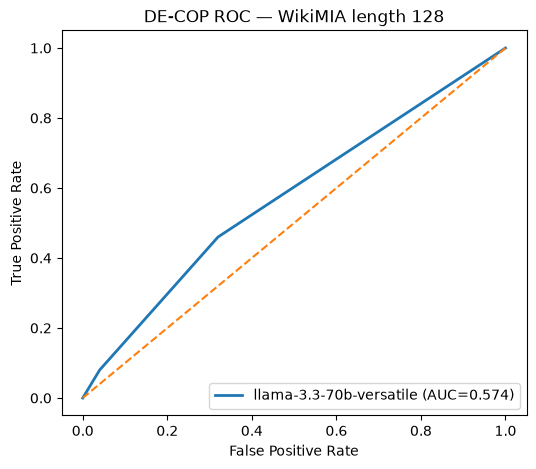


Métricas guardadas en:
/Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/results/decop_wikimia128_3options/llama-3.3-70b-versatile/decop_metrics_summary.csv


In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

print("Modelo:", MODEL)
print("Método: DE-COP adaptado a 3 opciones")
print("Dataset: WikiMIA_length128")
print("Samples completos:", len(sample_df))

print("\nMean Absolute Error:")
print(sample_df["absolute_error"].mean())

print("\nError por clase:")
print(sample_df.groupby("label")["absolute_error"].mean())

auc = None
tpr_at_5_fpr = None

if sample_df["label"].nunique() == 2:
    y = sample_df["label"].values
    scores = sample_df["membership_score"].values

    auc = roc_auc_score(y, scores)
    auc_inverted = roc_auc_score(y, -scores)

    print("\nAUC:", auc)
    print("AUC invertido:", auc_inverted)

    fpr, tpr, _ = roc_curve(y, scores)

    valid_tpr = tpr[fpr <= 0.05]
    tpr_at_5_fpr = valid_tpr.max() if len(valid_tpr) > 0 else 0.0

    print("TPR@5%FPR:", tpr_at_5_fpr)

    plt.figure(figsize=(6, 5))
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{MODEL} (AUC={auc:.3f})"
    )
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("DE-COP ROC — WikiMIA length 128")
    plt.legend(loc="lower right")
    plt.show()

else:
    print("\nTodavía no se puede calcular AUC: falta una de las clases.")


metrics_path = MODEL_RESULTS_DIR / "decop_metrics_summary.csv"

metrics_summary = pd.DataFrame([{
    "method": METHOD,
    "model": MODEL,
    "backend": BACKEND,
    "dataset": "WikiMIA",
    "split": "WikiMIA_length128",
    "n_options": 3,
    "n_permutations": N_PERMUTATIONS,
    "n_samples": len(sample_df),
    "n_members": int((sample_df["label"] == 1).sum()),
    "n_non_members": int((sample_df["label"] == 0).sum()),
    "mean_absolute_error": sample_df["absolute_error"].mean(),
    "mean_error_members": (
        sample_df.loc[
            sample_df["label"] == 1,
            "absolute_error"
        ].mean()
    ),
    "mean_error_non_members": (
        sample_df.loc[
            sample_df["label"] == 0,
            "absolute_error"
        ].mean()
    ),
    "auc": auc,
    "tpr_at_5_fpr": tpr_at_5_fpr,
}])

metrics_summary.to_csv(metrics_path, index=False)

print("\nMétricas guardadas en:")
print(metrics_path)

## Para escalar a "todos los modelos que BookTection permite"

1. Validá con la config chica de arriba (Groq, llama-3.1-8b-instant).
2. Subí `N_BOOKS_PER_CLASS=None`, `N_PASSAGES_PER_BOOK=None`, `N_PERMUTATIONS=24` para el run completo
   (ojo con el cap diario de Groq: ~14.4k req/día en el 8B; el resto 1k/día).
3. Cambiá `MODEL` y volvé a correr — cada modelo guarda su propio CSV.
   - **Groq (sin GPU):** `llama-3.3-70b-versatile`, `gemma2-9b-it`, `qwen-2.5-32b`, `mixtral-8x7b-32768`.
   - **HF en GPU (`BACKEND="hf"`, tus créditos):** `meta-llama/Llama-2-7b-chat-hf` (el limpio para
     BookTection), `mistralai/Mistral-7B-Instruct-v0.3`, `Qwen/Qwen2.5-7B-Instruct`, `google/gemma-2-9b-it`.
4. Para comparar modelos: juntá los CSV y graficá los AUC. Recordá el caveat temporal: para modelos
   con cutoff 2023+ el AUC de BookTection mezcla memorización real con contaminación de los non-members.
